# Preparación de datos demográficos de OWID (2000–2022)

**Objetivo:** descargar cuatro conjuntos de datos, revisar sus columnas, preparar cada uno por separado y unirlos por `Entity` y `Year`. El resultado servirá para una práctica posterior de aprendizaje automático.

Ejecuta las celdas en orden. Requiere `pandas` y `matplotlib`, además de acceso a internet. Fuente: [Our World in Data](https://ourworldindata.org/).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

OPCIONES_OWID = {"User-Agent": "Our World In Data data fetch/1.0"}
BASE = "https://ourworldindata.org/grapher/"
SUFIJO = ".csv?v=1&csvType=full&useColumnShortNames=true"

## 1. Descargar los cuatro archivos

Las direcciones son cadenas de texto simples. Cada archivo se carga en su propio DataFrame.

In [2]:
url_population = BASE + "population-with-un-projections" + SUFIJO
url_births = BASE + "number-of-births-per-year" + SUFIJO
url_deaths = BASE + "number-of-deaths-per-year" + SUFIJO
url_child_deaths = BASE + "number-of-child-deaths-unwpp" + SUFIJO

population = pd.read_csv(url_population, storage_options=OPCIONES_OWID)
births = pd.read_csv(url_births, storage_options=OPCIONES_OWID)
deaths = pd.read_csv(url_deaths, storage_options=OPCIONES_OWID)
child_deaths = pd.read_csv(url_child_deaths, storage_options=OPCIONES_OWID)

print("Filas y columnas:")
print("population:", population.shape)
print("births:", births.shape)
print("deaths:", deaths.shape)
print("child_deaths:", child_deaths.shape)

Filas y columnas:
population: (39562, 5)
births: (39109, 5)
deaths: (38656, 5)
child_deaths: (18942, 4)


## 2. Explorar las columnas

OWID puede modificar los nombres de los indicadores. Revisamos las columnas reales antes de seleccionarlas.

In [3]:
for nombre, tabla in [("population", population), 
                      ("births", births),
                      ("deaths", deaths), 
                      ("child_deaths", child_deaths)]:
    print(f"\n{nombre}: {tabla.columns.tolist()}")
    display(tabla.head(3))


population: ['entity', 'code', 'year', 'population__sex_all__age_all__variant_estimates', 'population__sex_all__age_all__variant_medium__projected']


,entity,code,year,population__sex_all__age_all__variant_estimates,population__sex_all__age_all__variant_medium__projected
0,Afghanistan,AFG,1950,7776180.0,NaN
1,Afghanistan,AFG,1951,7879343.0,NaN
2,Afghanistan,AFG,1952,7987784.0,NaN



births: ['entity', 'code', 'year', 'births__sex_all__age_all__variant_estimates', 'births__sex_all__age_all__variant_medium__projected']


,entity,code,year,births__sex_all__age_all__variant_estimates,births__sex_all__age_all__variant_medium__projected
0,Afghanistan,AFG,1950,383985.0,NaN
1,Afghanistan,AFG,1951,391002.0,NaN
2,Afghanistan,AFG,1952,397663.0,NaN



deaths: ['entity', 'code', 'year', 'deaths__sex_all__age_all__variant_estimates', 'deaths__sex_all__age_all__variant_medium__projected']


,entity,code,year,deaths__sex_all__age_all__variant_estimates,deaths__sex_all__age_all__variant_medium__projected
0,Afghanistan,AFG,1950,290972.0,NaN
1,Afghanistan,AFG,1951,288752.0,NaN
2,Afghanistan,AFG,1952,288059.0,NaN



child_deaths: ['entity', 'code', 'year', 'deaths__sex_all__age_0_4__variant_estimates']


,entity,code,year,deaths__sex_all__age_0_4__variant_estimates
0,Afghanistan,AFG,1950,160791
1,Afghanistan,AFG,1951,158566
2,Afghanistan,AFG,1952,157832


## 3. Preparar población

Elegimos la columna de **estimaciones históricas** para ambos sexos y todas las edades; excluimos las proyecciones. Después conservamos los años de interés.

In [4]:
columnas_population = [
    columna for columna in population.columns
        if "population" in columna and "estimates" in columna]

print("Columnas candidatas:", columnas_population)

assert len(columnas_population) == 1, "Revisar manualmente el indicador de población mostrado arriba"


col_population = columnas_population[0]

population_limpio = population[["entity", "year", col_population]].copy()

population_limpio = population_limpio.rename(columns={col_population: "population"})

population_limpio = population_limpio[population_limpio["year"].between(2000, 2022)].copy()

print(population_limpio.shape)
display(population_limpio.head())

Columnas candidatas: ['population__sex_all__age_all__variant_estimates']
(6026, 3)


,entity,year,population
50,Afghanistan,2000,20130334.0
51,Afghanistan,2001,20284303.0
52,Afghanistan,2002,21378123.0
53,Afghanistan,2003,22733053.0
54,Afghanistan,2004,23560656.0


## 4. Preparar nacimientos

Seleccionamos el número anual de nacimientos históricos. Revisamos qué entidades comparte con las otras tablas.

In [5]:
columnas_births = [c for c in births.columns
                  if "births" in c and "estimates" in c]


print("Columnas candidatas:", columnas_births)
assert len(columnas_births) == 1, "Revisar manualmente el indicador de nacimientos mostrado arriba"
col_births = columnas_births[0]

births_limpio = births[["entity", "year", col_births]].copy()
births_limpio = births_limpio.rename(columns={col_births: "births"})
births_limpio = births_limpio[births_limpio["year"].between(2000, 2022)].copy()
print(births_limpio.shape)
display(births_limpio.head())

Columnas candidatas: ['births__sex_all__age_all__variant_estimates']
(5957, 3)


,entity,year,births
50,Afghanistan,2000,1036525.0
51,Afghanistan,2001,1006562.0
52,Afghanistan,2002,1015202.0
53,Afghanistan,2003,1069727.0
54,Afghanistan,2004,1095372.0


## 5. Preparar defunciones totales

In [6]:
columnas_deaths = [c for c in deaths.columns
                   if "deaths" in c and "estimates" in c]

print("Columnas candidatas:", columnas_deaths)
assert len(columnas_deaths) == 1, "Revisar manualmente el indicador de defunciones mostrado arriba"

col_deaths = columnas_deaths[0]

deaths_limpio = deaths[["entity", "year", col_deaths]].copy()
deaths_limpio = deaths_limpio.rename(columns={col_deaths: "deaths"})
deaths_limpio = deaths_limpio[deaths_limpio["year"].between(2000, 2022)].copy()

print(deaths_limpio.shape)
display(deaths_limpio.head())

Columnas candidatas: ['deaths__sex_all__age_all__variant_estimates']
(5888, 3)


,entity,year,deaths
50,Afghanistan,2000,253804.0
51,Afghanistan,2001,242473.0
52,Afghanistan,2002,239161.0
53,Afghanistan,2003,243573.0
54,Afghanistan,2004,244435.0


## 6. Preparar defunciones de menores de cinco años

Este indicador corresponde a niños de 0 a 4 años; no debe confundirse con mortalidad de menores de un año.

In [7]:
columnas_child = [c for c in child_deaths.columns
                  if c not in ["entity", "code", "year"]]

print("Columnas candidatas:", columnas_child)

assert len(columnas_child) == 1, "Revisar manualmente el indicador de menores de cinco años mostrado arriba"

col_child = columnas_child[0]

child_deaths_limpio = child_deaths[["entity", "year", col_child]].copy()
child_deaths_limpio = child_deaths_limpio.rename(columns={col_child: "child_deaths_under_5"})

child_deaths_limpio = child_deaths_limpio[child_deaths_limpio["year"].between(2000, 2022)].copy()

print(child_deaths_limpio.shape)
display(child_deaths_limpio.head())

Columnas candidatas: ['deaths__sex_all__age_0_4__variant_estimates']
(5887, 3)


,entity,year,child_deaths_under_5
50,Afghanistan,2000,133112
51,Afghanistan,2001,125627
52,Afghanistan,2002,123215
53,Afghanistan,2003,123894
54,Afghanistan,2004,122315


## 7. Revisar llaves y cobertura

Cada combinación `Entity`–`Year` debe aparecer una sola vez en cada tabla. `Code` no se utiliza como llave porque puede faltar en agregados regionales.

In [8]:
tablas = [("population", population_limpio), ("births", births_limpio),
          ("deaths", deaths_limpio), ("child_deaths", child_deaths_limpio)]

for nombre, tabla in tablas:
    duplicados = tabla.duplicated(["entity", "year"]).sum()
    print(nombre, "| entidades:", tabla["entity"].nunique(),
          "| años:", tabla["year"].min(), "a", tabla["year"].max(),
          "| llaves duplicadas:", duplicados)
    assert duplicados == 0, f"Llaves duplicadas en {nombre}"

entidades_comunes = set(population_limpio["entity"]) & set(births_limpio["entity"]) \
                  & set(deaths_limpio["entity"]) & set(child_deaths_limpio["entity"])

print("Entidades presentes en los cuatro archivos:", len(entidades_comunes))
print(sorted(entidades_comunes)[:30])

population | entidades: 262 | años: 2000 a 2022 | llaves duplicadas: 0
births | entidades: 259 | años: 2000 a 2022 | llaves duplicadas: 0
deaths | entidades: 256 | años: 2000 a 2022 | llaves duplicadas: 0
child_deaths | entidades: 256 | años: 2000 a 2022 | llaves duplicadas: 0
Entidades presentes en los cuatro archivos: 253
['Afghanistan', 'Africa (UN)', 'Albania', 'Algeria', 'American Samoa', 'Andorra', 'Angola', 'Anguilla', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba', 'Asia (UN)', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan', 'Bolivia', 'Bonaire Sint Eustatius and Saba', 'Bosnia and Herzegovina', 'Botswana']


## 8. Unir las tablas, un paso a la vez

Usamos `inner`: permanecen únicamente las combinaciones de entidad y año presentes en ambos DataFrames. `validate="one_to_one"` detecta llaves duplicadas.

In [9]:
population_births = pd.merge(
    population_limpio, births_limpio,
    on=["entity", "year"], how="inner", validate="one_to_one"
)
print("Después de población + nacimientos:", population_births.shape)
display(population_births.head())

Después de población + nacimientos: (5957, 4)


,entity,year,population,births
0,Afghanistan,2000,20130334.0,1036525.0
1,Afghanistan,2001,20284303.0,1006562.0
2,Afghanistan,2002,21378123.0,1015202.0
3,Afghanistan,2003,22733053.0,1069727.0
4,Afghanistan,2004,23560656.0,1095372.0


In [10]:
population_births_deaths = pd.merge(
    population_births, deaths_limpio,
    on=["entity", "year"], how="inner", validate="one_to_one"
)
print("Después de agregar defunciones:", population_births_deaths.shape)
display(population_births_deaths.head())

Después de agregar defunciones: (5819, 5)


,entity,year,population,births,deaths
0,Afghanistan,2000,20130334.0,1036525.0,253804.0
1,Afghanistan,2001,20284303.0,1006562.0,242473.0
2,Afghanistan,2002,21378123.0,1015202.0,239161.0
3,Afghanistan,2003,22733053.0,1069727.0,243573.0
4,Afghanistan,2004,23560656.0,1095372.0,244435.0


In [11]:
demografia = pd.merge(
    population_births_deaths, child_deaths_limpio,
    on=["entity", "year"], how="inner", validate="one_to_one"
)
print("Dataset unido:", demografia.shape)
display(demografia.head())

Dataset unido: (5818, 6)


,entity,year,population,births,deaths,child_deaths_under_5
0,Afghanistan,2000,20130334.0,1036525.0,253804.0,133112
1,Afghanistan,2001,20284303.0,1006562.0,242473.0,125627
2,Afghanistan,2002,21378123.0,1015202.0,239161.0,123215
3,Afghanistan,2003,22733053.0,1069727.0,243573.0,123894
4,Afghanistan,2004,23560656.0,1095372.0,244435.0,122315


## 9. Revisar faltantes y crear tasas

Eliminamos solo filas con algún indicador necesario ausente. Las tasas de nacimientos y defunciones se expresan por 1,000 habitantes. La razón de muertes de menores de cinco años usa nacimientos del **mismo año** como denominador; es una medida descriptiva aproximada, no una tasa de mortalidad de cohorte.

In [12]:
print("Valores faltantes antes de limpiar:")
print(demografia.isna().sum())
print("Filas antes de limpiar:", len(demografia))

demografia = demografia.dropna(subset=["population", "births", "deaths", "child_deaths_under_5"]).copy()
demografia = demografia[(demografia["population"] > 0) & (demografia["births"] > 0)].copy()

print("Filas después de limpiar:", len(demografia))
print("Entidades después de limpiar:", demografia["entity"].nunique())
assert not demografia.empty, "No hay entidades y años coincidentes; revisar fuentes y columnas"

Valores faltantes antes de limpiar:
entity                  0
year                    0
population              0
births                  0
deaths                  0
child_deaths_under_5    0
dtype: int64
Filas antes de limpiar: 5818
Filas después de limpiar: 5818
Entidades después de limpiar: 253


In [13]:
demografia["birth_rate_per_1000"] = demografia["births"] / demografia["population"] * 1000
demografia["death_rate_per_1000"] = demografia["deaths"] / demografia["population"] * 1000
demografia["under5_deaths_per_1000_births_same_year"] = (
    demografia["child_deaths_under_5"] / demografia["births"] * 1000
)

demografia = demografia[[
    "entity", "year", "population", "births", "deaths", "child_deaths_under_5",
    "birth_rate_per_1000", "death_rate_per_1000",
    "under5_deaths_per_1000_births_same_year"
]].sort_values(["entity", "year"]).reset_index(drop=True)

display(demografia.head())
display(demografia.describe(include="all"))

,entity,year,population,births,deaths,child_deaths_under_5,birth_rate_per_1000,death_rate_per_1000,under5_deaths_per_1000_births_same_year
0,Afghanistan,2000,20130334.0,1036525.0,253804.0,133112,51.490701,12.608037,128.421408
1,Afghanistan,2001,20284303.0,1006562.0,242473.0,125627,49.622706,11.953726,124.808010
2,Afghanistan,2002,21378123.0,1015202.0,239161.0,123215,47.487892,11.187184,121.369934
3,Afghanistan,2003,22733053.0,1069727.0,243573.0,123894,47.056020,10.714487,115.818335
4,Afghanistan,2004,23560656.0,1095372.0,244435.0,122315,46.491575,10.374711,111.665261


,entity,year,population,births,deaths,child_deaths_under_5,birth_rate_per_1000,death_rate_per_1000,under5_deaths_per_1000_births_same_year
count,5818,5818.000000,5.818000e+03,5.818000e+03,5.818000e+03,5.818000e+03,5818.000000,5818.000000,5818.000000
unique,253,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2010.998109,1.813646e+08,3.694664e+06,1.412358e+06,1.996904e+05,20.689316,8.090787,33.575744
std,NaN,6.632822,8.095803e+08,1.664067e+07,6.115319e+06,9.607351e+05,10.726673,3.394544,38.770408
min,NaN,2000.000000,5.130000e+02,2.000000e+00,0.000000e+00,0.000000e+00,3.502627,0.000000,0.000000
25%,NaN,2005.000000,4.223308e+05,7.034000e+03,2.642000e+03,9.100000e+01,11.679919,6.036428,7.729453
50%,NaN,2011.000000,5.570254e+06,9.391100e+04,4.326450e+04,1.526000e+03,17.747819,7.558672,17.452421
75%,NaN,2017.000000,2.581040e+07,6.027868e+05,2.003098e+05,2.329175e+04,28.068762,9.756676,45.791458


## 10. Visualizar una entidad disponible

Puedes cambiar `entidad` por cualquier nombre de `demografia["Entity"].unique()`.

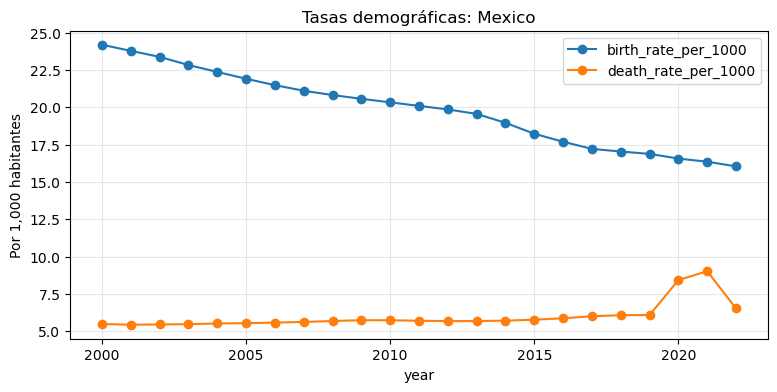

In [14]:
entidad = "Mexico" if "Mexico" in demografia["entity"].values else demografia["entity"].iloc[0]
ejemplo = demografia[demografia["entity"] == entidad].sort_values("year")

ejemplo.plot(x="year", y=["birth_rate_per_1000", "death_rate_per_1000"],
             marker="o", figsize=(9, 4), title=f"Tasas demográficas: {entidad}")
plt.ylabel("Por 1,000 habitantes")
plt.grid(alpha=0.3)
plt.show()

## 11. Guardar el resultado

El CSV se guarda junto al notebook. Contiene solamente entidades y años compartidos por las cuatro fuentes.

In [15]:
from pathlib import Path

carpeta_salida = Path("../data/processed")
carpeta_salida.mkdir(parents=True, exist_ok=True)

salida = carpeta_salida / "demografia_owid_2000_2022.csv"
demografia.to_csv(salida, index=False)

print(f"Archivo guardado: {salida.resolve()} | filas: {len(demografia)}")

Archivo guardado: C:\Users\aaron\OneDrive\Documentos\Escuela\5to Semestre\Big Data\big_data_aaron\U3_1_modelos_regresion_demografia\data\processed\demografia_owid_2000_2022.csv | filas: 5818


In [17]:
# Carga de los datasets de salud y PIB
url_health = "https://ourworldindata.org/grapher/total-healthcare-expenditure-gdp.csv?v=1&csvType=full&useColumnShortNames=true"
url_gdp = "https://ourworldindata.org/grapher/gdp-per-capita-worldbank.csv?v=1&csvType=full&useColumnShortNames=true"

health = pd.read_csv(url_health, storage_options={'User-Agent': 'Our World In Data data fetch/1.0'})
gdp = pd.read_csv(url_gdp, storage_options={'User-Agent': 'Our World In Data data fetch/1.0'})

print("Health cargado:", health.shape)
print("GDP cargado:", gdp.shape)

Health cargado: (4756, 4)
GDP cargado: (7445, 5)


In [18]:
# 1. Preparar Health Percentage
col_health = [
    c for c in health.columns if c not in ["entity", "code", "year"]
][0]

health_limpio = health[["entity", "year", col_health]].copy()
health_limpio = health_limpio.rename(columns={col_health: "percentage_health"})
health_limpio = health_limpio[
    health_limpio["year"].between(2000, 2022)
].copy()

# 2. Preparar GDP
col_gdp = [c for c in gdp.columns if c not in ["entity", "code", "year"]][0]

gdp_limpio = gdp[["entity", "year", col_gdp]].copy()
gdp_limpio = gdp_limpio.rename(columns={col_gdp: "gdp"})
gdp_limpio = gdp_limpio[gdp_limpio["year"].between(2000, 2022)].copy()

In [19]:
# Unir demografia con health
demografia_completo = pd.merge(
    demografia, health_limpio, on=["entity", "year"], how="inner"
)

# Unir con gdp
demografia_completo = pd.merge(
    demografia_completo, gdp_limpio, on=["entity", "year"], how="inner"
)

# Quedarse con las 8 columnas exactas solicitadas
columnas_finales = [
    "entity",
    "year",
    "population",
    "births",
    "deaths",
    "child_deaths_under_5",
    "percentage_health",
    "gdp",
]

dataset_final = demografia_completo[columnas_finales].copy()
dataset_final = dataset_final.dropna().reset_index(drop=True)

print("Dimensiones finales:", dataset_final.shape)
print("Columnas:", dataset_final.columns.tolist())
display(dataset_final.head())

Dimensiones finales: (4244, 8)
Columnas: ['entity', 'year', 'population', 'births', 'deaths', 'child_deaths_under_5', 'percentage_health', 'gdp']


,entity,year,population,births,deaths,child_deaths_under_5,percentage_health,gdp
0,Afghanistan,2002,21378123.0,1015202.0,239161.0,123215,9.443391,1774.3087
1,Afghanistan,2003,22733053.0,1069727.0,243573.0,123894,8.941258,1815.9282
2,Afghanistan,2004,23560656.0,1095372.0,244435.0,122315,9.808474,1776.9182
3,Afghanistan,2005,24404575.0,1097038.0,241932.0,118420,9.948289,1908.1147
4,Afghanistan,2006,25424100.0,1120880.0,245586.0,116622,10.622766,1929.7239
